In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
# Fashion Color Analyzer 🎨

This project analyzes fashion outfit images and extracts the dominant colors using KMeans clustering.

The goal is to identify common color trends in fashion datasets.

In [ ]:
## 1. Load Images

We load all images from the dataset folder and count how many images we are working with.

In [5]:
import os

IMAGE_FOLDER = "../images"

files = os.listdir(IMAGE_FOLDER)

print(files)
print("Number of images:", len(files))

['#outfits #fashion #summer #summerstyle.jpg', '30 Effortlessly Chic Outfits to Copy for Summer.jpg', '5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg', 'Another Day in Denim.jpg', 'download (1).jpg', 'download (2).jpg', 'download (3).jpg', 'download (4).jpg', 'download (5).jpg', 'download.jpg', 'Elegant Spring Outfit Inspo _ Effortlessly Chic Cafe Baddie Look 2026.jpg', 'Elegant Street Style _ Fashion Essentials.jpg', 'Ellie (@slipintostyle) • Instagram photos and videos.jpg', 'Find Out Where To Get The Top.jpg', 'Jordan Clarkson Outfits.jpg', 'Jordan Clarkson.jpg', 'LAURA JADE NUDE HIGH WAISTED MIDI SKIRT WITH BUTTON SIDE SPLIT.jpg', 'lewis hamilton.jpg', 'lucyflorals on LTK.jpg', 'Mens Fashion.jpg', 'Oversize Parrot Retro Tee.jpg', 'PSYLOS1 - Designer Clothing and Sneakers _ Shop for Fashion.jpg', 'Rose.jpg', 'ShopStyle.jpg', 'THE DAILEIGH Where To Start.jpg']
Number of images: 25


In [6]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
## 2. Extract Dominant Colors

We use KMeans clustering to extract the most dominant colors from each image.

In [7]:
def get_dominant_colors(image_path, k=3):
    image = Image.open(image_path)
    image = image.resize((150, 150))
    
    pixels = np.array(image).reshape(-1, 3)
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixels)
    
    colors = kmeans.cluster_centers_
    
    return colors

In [8]:
test_image = os.path.join(IMAGE_FOLDER, files[0])

colors = get_dominant_colors(test_image)

print(colors)

[[185.30375293 185.19917905 180.85154418]
 [ 37.97713951  33.80285268  31.28898007]
 [124.20937063 121.40699301 119.04125874]]


In [ ]:
## 3. Visualize Colors from One Image

Here we test our function on a single image to see the extracted dominant colors.

In [9]:
def show_colors(colors):
    plt.figure(figsize=(6, 2))
    plt.imshow([colors.astype(int)])
    plt.axis('off')
    plt.show()

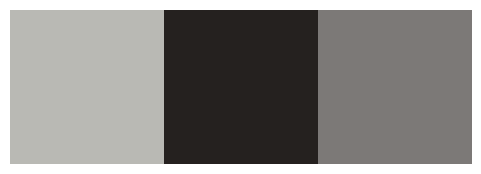

In [10]:
show_colors(colors)

In [ ]:
## 4. Analyze All Images

We loop through all images and collect dominant colors from each one.

In [11]:
all_colors = []

for file in files:
    image_path = os.path.join(IMAGE_FOLDER, file)
    
    try:
        colors = get_dominant_colors(image_path)
        all_colors.extend(colors)
    except:
        print(f"Skipped: {file}")

all_colors = np.array(all_colors)
print("Total colors collected:", len(all_colors))

Total colors collected: 75


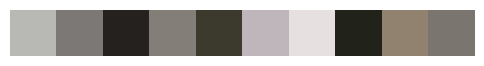

In [12]:
show_colors(all_colors[:10])

In [ ]:
## 5. Find Main Color Trends

We apply KMeans again on all collected colors to identify overall fashion color trends.

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(all_colors)

main_colors = kmeans.cluster_centers_

print(main_colors)

[[219.73634294 217.16356384 213.42581425]
 [ 73.61064911  76.97340807  79.43342838]
 [186.86045409 176.9954252  162.07302099]
 [ 45.0658292   39.85819257  34.35913274]
 [138.57277324 124.46951207 111.18022802]]


C:\Users\ousama\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


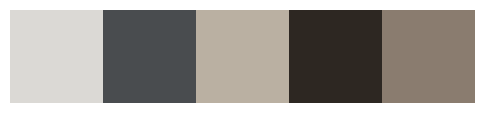

In [14]:
show_colors(main_colors)

In [ ]:
## 6. Color Distribution

We calculate how frequently each color appears in the dataset.

In [15]:
labels = kmeans.labels_

import numpy as np

unique, counts = np.unique(labels, return_counts=True)

for i in range(len(unique)):
    percentage = counts[i] / len(labels) * 100
    print(f"Color {i+1}: {percentage:.2f}%")

Color 1: 17.33%
Color 2: 13.33%
Color 3: 20.00%
Color 4: 24.00%
Color 5: 25.33%


In [16]:
for i, color in enumerate(main_colors):
    r, g, b = color.astype(int)
    print(f"Color {i+1}: RGB({r}, {g}, {b})")

Color 1: RGB(219, 217, 213)
Color 2: RGB(73, 76, 79)
Color 3: RGB(186, 176, 162)
Color 4: RGB(45, 39, 34)
Color 5: RGB(138, 124, 111)


In [ ]:
## 7. Conclusion

The dataset is dominated by neutral and earthy tones such as gray, black, beige, and brown.

This suggests a strong preference for minimal, versatile, and timeless fashion styles.

These insights could be useful for building recommendation systems or understanding fashion trends at scale.